# 03 — BigQuery ML Analysis

After dbt has transformed the data into `opp_budget.fct_budget_execution`, run ML experiments:

1. **Linear regression**: predict next-year budget allocation
2. **K-means clustering**: group incisos by spending patterns

## Setup

In [1]:
!pip install -q google-cloud-bigquery==3.27.0 db-dtypes==1.3.1 pyarrow==18.1.0 matplotlib==3.9.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.1/240.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 59.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.38.0 requires db-dtypes>=1.4.2, but you have db-dtypes 1.3.1 which is incompatible.
bigframes 2.38.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.36.0, but you have google-cloud-bigquery 3.27.0 which is incompatible.


In [2]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "fabled-imagery-488015-p6"
client = bigquery.Client(project=PROJECT_ID)

print(f"Connected to BigQuery project: {PROJECT_ID}")

Connected to BigQuery project: fabled-imagery-488015-p6


## Preview Data

In [3]:
query = """
SELECT *
FROM `opp_budget.fct_budget_execution`
ORDER BY fiscal_year DESC, total_credito_vigente DESC
LIMIT 20
"""
df = client.query(query).to_dataframe()
print(f"Rows: {len(df)}, Columns: {list(df.columns)}")
df.head(20)

Rows: 20, Columns: ['execution_id', 'fiscal_year', 'inciso', 'denominacion_inciso', 'categoria', 'total_credito_vigente', 'total_ejecucion', 'avg_execution_rate_pct', 'avg_credito_yoy_pct_change', 'record_count', 'source_count']


,execution_id,fiscal_year,inciso,denominacion_inciso,categoria,total_credito_vigente,total_ejecucion,avg_execution_rate_pct,avg_credito_yoy_pct_change,record_count,source_count
0,daafb247b09f8894567b6f2abef77eff,2024,3,Ministerio de Defensa Nacional,Recursos asignados al mantenimiento de los buques,2.024927e+07,NaN,NaN,NaN,1,1
1,a092f372328f849b04efc3db635d413d,2024,35,Ministerio de Defensa Nacional,Recursos asignados/Cantidad de unidades alistadas,9.939860e+06,NaN,NaN,480.02,1,1
2,d21af2b5f5b560690d126d59603baa7f,2024,3,Ministerio de Defensa Nacional,Recursos asignados a cursos y adiestramiento,6.764560e+05,NaN,NaN,NaN,1,1
3,4a4ca7483d5390ade67e09d8541ac24c,2024,3,Ministerio de Defensa Nacional,Recursos asignados para la atención del persona,2.591500e+04,NaN,NaN,NaN,1,1
4,07bfec2027fd433b96961878815770bf,2023,24,DIV. CRÉDITOS,INVERSIONES,1.561272e+10,NaN,NaN,NaN,1,1
5,f9d24bfe24c64da1dab29479e5f37fac,2023,10,M.T.O.P.,INVERSIONES,1.212180e+10,NaN,NaN,NaN,1,1
6,9a3e294c4fb6c51935c255d66de3af5f,2023,14,M.V.O.T.,INVERSIONES,1.181544e+10,NaN,NaN,NaN,1,1
7,1dbe65bc7ad64ec94d405915d9077259,2023,14,Ministerio de Vivienda y Ordenamiento Territorial,Prog de Rehabilitación y Consolidación Urbano ...,1.142294e+10,NaN,NaN,NaN,1,1
8,21129bbfd1a7430a5701d13a13646a97,2023,25,A.N.E.P.,INVERSIONES,3.498427e+09,NaN,NaN,NaN,1,1
9,1b993ced10effc6790d000f7cc5d7dc8,2023,21,SUBS. Y SUBV.,INVERSIONES,2.376495e+09,NaN,NaN,NaN,1,1


In [4]:
summary = client.query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT fiscal_year) AS distinct_years,
    COUNT(DISTINCT inciso) AS distinct_incisos,
    COUNT(DISTINCT categoria) AS distinct_categorias,
    MIN(fiscal_year) AS min_year,
    MAX(fiscal_year) AS max_year,
    SUM(total_credito_vigente) AS total_budget,
    SUM(total_ejecucion) AS total_ejecucion
FROM `opp_budget.fct_budget_execution`
""").to_dataframe()
summary

,total_rows,distinct_years,distinct_incisos,distinct_categorias,min_year,max_year,total_budget,total_ejecucion
0,1808,20,164,375,2005,2024,3.679091e+12,1.116758e+12


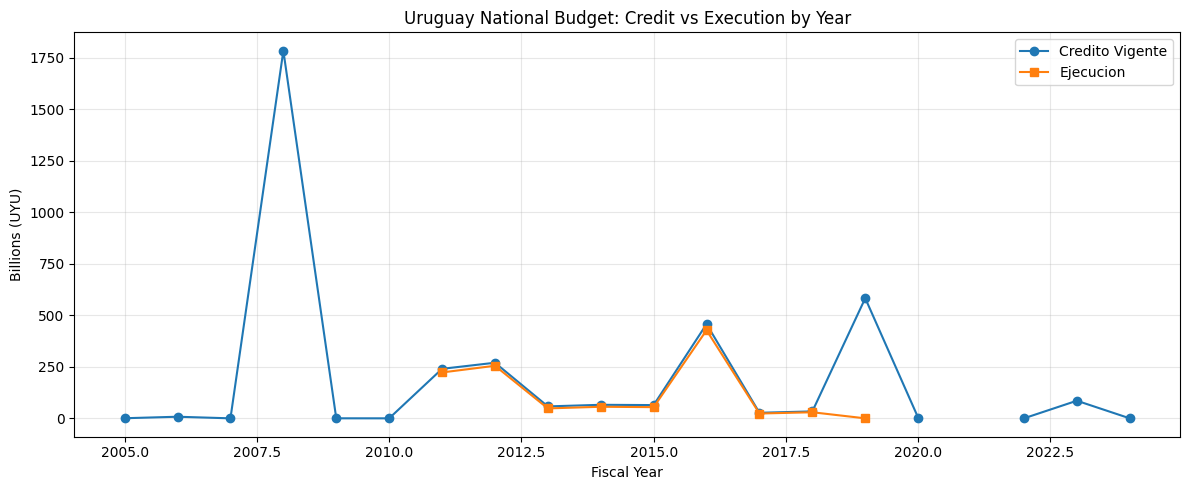

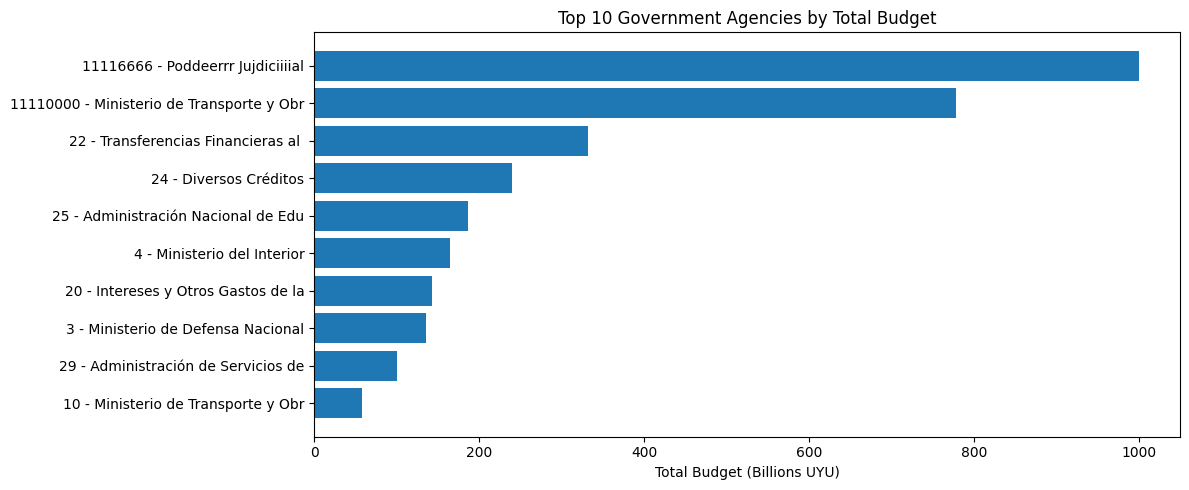

In [5]:
import matplotlib.pyplot as plt

# Budget evolution by year
yearly = client.query("""
SELECT
    fiscal_year,
    SUM(total_credito_vigente) AS credito,
    SUM(total_ejecucion) AS ejecucion
FROM `opp_budget.fct_budget_execution`
GROUP BY fiscal_year
ORDER BY fiscal_year
""").to_dataframe()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly["fiscal_year"], yearly["credito"] / 1e9, marker="o", label="Credito Vigente")
ax.plot(yearly["fiscal_year"], yearly["ejecucion"] / 1e9, marker="s", label="Ejecucion")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Billions (UYU)")
ax.set_title("Uruguay National Budget: Credit vs Execution by Year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Top 10 incisos by total budget
top_incisos = client.query("""
SELECT
    inciso,
    denominacion_inciso,
    SUM(total_credito_vigente) AS total_budget
FROM `opp_budget.fct_budget_execution`
GROUP BY inciso, denominacion_inciso
ORDER BY total_budget DESC
LIMIT 10
""").to_dataframe()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    [f"{r.inciso} - {r.denominacion_inciso[:30]}" for _, r in top_incisos.iterrows()],
    top_incisos["total_budget"] / 1e9,
)
ax.set_xlabel("Total Budget (Billions UYU)")
ax.set_title("Top 10 Government Agencies by Total Budget")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Experiment 1: Linear Regression — Budget Forecasting

In [6]:
# Create the model
create_model_sql = """
CREATE OR REPLACE MODEL `opp_budget.budget_forecast`
OPTIONS(
    model_type='LINEAR_REG',
    input_label_cols=['total_credito_vigente']
) AS
SELECT
    fiscal_year,
    inciso,
    COALESCE(avg_credito_yoy_pct_change, 0) AS yoy_change,
    COALESCE(avg_execution_rate_pct, 0) AS exec_rate,
    total_credito_vigente
FROM `opp_budget.fct_budget_execution`
WHERE total_credito_vigente IS NOT NULL
  AND total_credito_vigente > 0
"""

print("Training linear regression model...")
client.query(create_model_sql).result()
print("Model created: opp_budget.budget_forecast")

Training linear regression model...
Model created: opp_budget.budget_forecast


In [7]:
# Evaluate
eval_df = client.query("""
SELECT * FROM ML.EVALUATE(MODEL `opp_budget.budget_forecast`)
""").to_dataframe()
print("Model evaluation metrics:")
eval_df

Model evaluation metrics:


,mean_absolute_error,mean_squared_error,mean_squared_log_error,median_absolute_error,r2_score,explained_variance
0,3.789301e+09,7.508316e+19,62.527517,2.465212e+09,-0.911697,-0.845749


In [8]:
# Predict next year's budget for top incisos
predict_df = client.query("""
SELECT
    p.inciso,
    f.denominacion_inciso,
    p.predicted_total_credito_vigente,
    p.total_credito_vigente AS actual
FROM ML.PREDICT(MODEL `opp_budget.budget_forecast`,
    (SELECT
        fiscal_year + 1 AS fiscal_year,
        inciso,
        COALESCE(avg_credito_yoy_pct_change, 0) AS yoy_change,
        COALESCE(avg_execution_rate_pct, 0) AS exec_rate,
        total_credito_vigente
    FROM `opp_budget.fct_budget_execution`
    WHERE fiscal_year = (SELECT MAX(fiscal_year) FROM `opp_budget.fct_budget_execution`)
      AND total_credito_vigente IS NOT NULL)
) p
LEFT JOIN (
    SELECT DISTINCT inciso, denominacion_inciso
    FROM `opp_budget.fct_budget_execution`
) f ON p.inciso = f.inciso
ORDER BY p.predicted_total_credito_vigente DESC
LIMIT 15
""").to_dataframe()
print("Budget predictions for next fiscal year (top 15):")
predict_df

Budget predictions for next fiscal year (top 15):


,inciso,denominacion_inciso,predicted_total_credito_vigente,actual
0,35,Ministerio de Defensa Nacional,9.081391e+07,9939860.0
1,35,Instituto Nacional de Inclusión Social Adolesc...,9.081391e+07,9939860.0
2,35,Instituto Nacional de Inclusion Social Adolesc...,9.081391e+07,9939860.0
3,35,I.N.I.S.A.,9.081391e+07,9939860.0
4,3,Ministerio de Vivienda,9.075076e+07,25915.0
5,3,Ministerio de Defensa Nacional - Dirección Nac...,9.075076e+07,25915.0
6,3,Rutas Culturales,9.075076e+07,25915.0
7,3,Consultorías Cursos de calidad Unidad,9.075076e+07,25915.0
8,3,MINISTRO DE DEFENSA NACIONAL,9.075076e+07,25915.0
9,3,Auditoría Interna de la Nación,9.075076e+07,25915.0


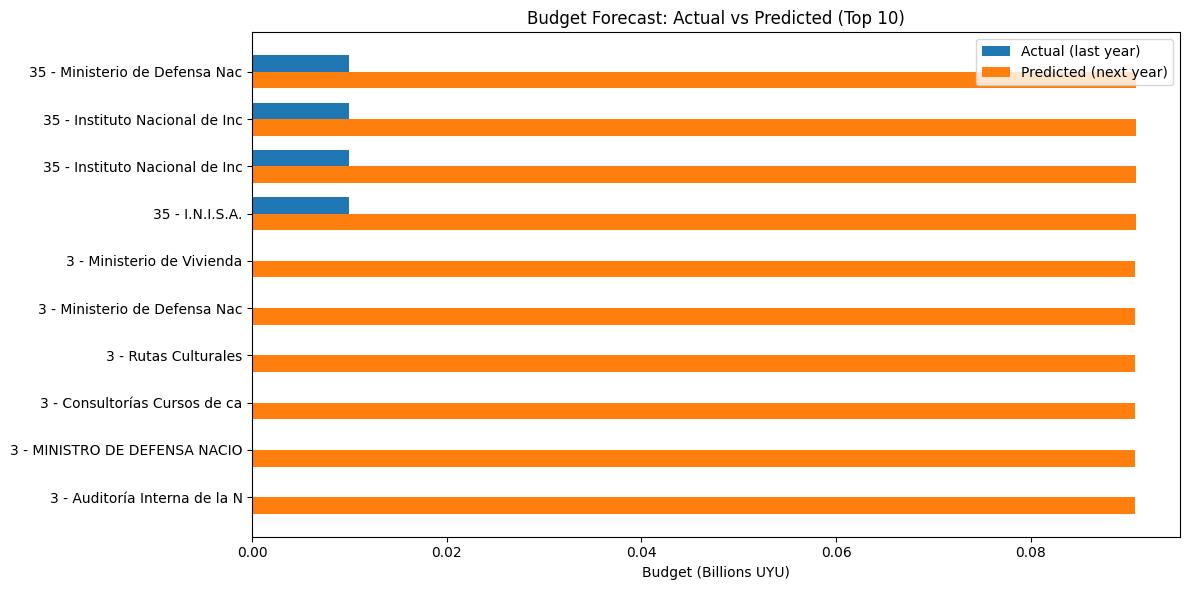

In [9]:
# Visualize predictions vs actual
fig, ax = plt.subplots(figsize=(12, 6))
labels = [f"{r.inciso} - {str(r.denominacion_inciso)[:25]}" for _, r in predict_df.head(10).iterrows()]
x = range(len(labels))
width = 0.35
ax.barh([i - width/2 for i in x], predict_df.head(10)["actual"] / 1e9, width, label="Actual (last year)")
ax.barh([i + width/2 for i in x], predict_df.head(10)["predicted_total_credito_vigente"] / 1e9, width, label="Predicted (next year)")
ax.set_yticks(list(x))
ax.set_yticklabels(labels)
ax.set_xlabel("Budget (Billions UYU)")
ax.set_title("Budget Forecast: Actual vs Predicted (Top 10)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Experiment 2: K-Means Clustering — Spending Patterns

In [10]:
# Create clustering model
kmeans_sql = """
CREATE OR REPLACE MODEL `opp_budget.inciso_clusters`
OPTIONS(
    model_type='KMEANS',
    num_clusters=5
) AS
SELECT
    inciso,
    AVG(total_credito_vigente) AS avg_budget,
    AVG(total_ejecucion) AS avg_execution,
    AVG(COALESCE(avg_execution_rate_pct, 0)) AS avg_exec_rate,
    AVG(COALESCE(avg_credito_yoy_pct_change, 0)) AS avg_yoy_change,
    COUNT(DISTINCT fiscal_year) AS years_active
FROM `opp_budget.fct_budget_execution`
WHERE total_credito_vigente IS NOT NULL
GROUP BY inciso
"""

print("Training K-Means clustering model...")
client.query(kmeans_sql).result()
print("Model created: opp_budget.inciso_clusters")

Training K-Means clustering model...
Model created: opp_budget.inciso_clusters


In [11]:
# View cluster assignments with agency names
clusters_df = client.query("""
SELECT
    p.CENTROID_ID,
    p.inciso,
    f.denominacion_inciso,
    p.avg_budget,
    p.avg_execution,
    p.avg_exec_rate,
    p.avg_yoy_change
FROM ML.PREDICT(MODEL `opp_budget.inciso_clusters`,
    (SELECT
        inciso,
        AVG(total_credito_vigente) AS avg_budget,
        AVG(total_ejecucion) AS avg_execution,
        AVG(COALESCE(avg_execution_rate_pct, 0)) AS avg_exec_rate,
        AVG(COALESCE(avg_credito_yoy_pct_change, 0)) AS avg_yoy_change,
        COUNT(DISTINCT fiscal_year) AS years_active
    FROM `opp_budget.fct_budget_execution`
    WHERE total_credito_vigente IS NOT NULL
    GROUP BY inciso)
) p
LEFT JOIN (
    SELECT DISTINCT inciso, denominacion_inciso
    FROM `opp_budget.fct_budget_execution`
) f ON p.inciso = f.inciso
ORDER BY CENTROID_ID, avg_budget DESC
""").to_dataframe()

print("Cluster assignments:")
clusters_df

Cluster assignments:


,CENTROID_ID,inciso,denominacion_inciso,avg_budget,avg_execution,avg_exec_rate,avg_yoy_change
0,1,11110000,Ministerio de Transporte y Obras Públicas,1.111507e+11,NaN,0.000000,362.753333
1,1,23,Partidas a Reaplicar,3.714625e+09,0.000000e+00,0.000000,9485.853468
2,1,23,"TIC - Hardware (CF) Impresoras, scaners, multi...",3.714625e+09,0.000000e+00,0.000000,9485.853468
3,1,916,Centro para la Inclusión Tecnológica y Social,1.204000e+09,NaN,0.000000,0.000000
4,1,241,Fomento a la Investigación Académica,1.157305e+09,NaN,0.000000,0.000000
...,...,...,...,...,...,...,...
472,4,19,Tribunal de lo Contencioso Administrativo,2.772533e+07,2.911631e+07,30.859871,68484.610708
473,4,19,PROTECCIÓN SOCIAL,2.772533e+07,2.911631e+07,30.859871,68484.610708
474,4,19,Centro Hospitalario Pereira Rossell,2.772533e+07,2.911631e+07,30.859871,68484.610708
475,4,19,SELARENEG SATNER,2.772533e+07,2.911631e+07,30.859871,68484.610708


In [12]:
# Cluster summary with agency names
print("Cluster profiles:\n")
for cid in sorted(clusters_df["CENTROID_ID"].unique()):
    group = clusters_df[clusters_df["CENTROID_ID"] == cid]
    names = [f"{r.inciso}-{str(r.denominacion_inciso)[:30]}" for _, r in group.iterrows()]
    print(f"  Cluster {cid}: {len(group)} incisos")
    print(f"    Avg budget:     {group['avg_budget'].mean():,.0f}")
    print(f"    Avg exec rate:  {group['avg_exec_rate'].mean():.1f}%")
    print(f"    Avg YoY change: {group['avg_yoy_change'].mean():.1f}%")
    print(f"    Agencies:       {', '.join(names[:5])}")
    if len(names) > 5:
        print(f"                    ... and {len(names) - 5} more")
    print()

Cluster profiles:

  Cluster 1: 187 incisos
    Avg budget:     706,336,621
    Avg exec rate:  2.0%
    Avg YoY change: 1534.1%
    Agencies:       11110000-Ministerio de Transporte y Obr, 23-Partidas a Reaplicar, 23-TIC - Hardware (CF) Impresoras, 916-Centro para la Inclusión Tecno, 241-Fomento a la Investigación Aca
                    ... and 182 more

  Cluster 2: 7 incisos
    Avg budget:     27,361,070
    Avg exec rate:  0.0%
    Avg YoY change: -0.3%
    Agencies:       50082500-SALTO TIC, 40066000-SAN JOSE TIC, 40066000-TACUAREMBO TIC, 30049500-SORIANO TIC, 36665555-Desarrollo del Gobierno Electr
                    ... and 2 more

  Cluster 3: 49 incisos
    Avg budget:     3,028,485,163
    Avg exec rate:  2193893.0%
    Avg YoY change: 7908659.9%
    Agencies:       24-Presidencia de la República: I, 24-Diversos Créditos, 24-Presidencia: (Transferencia a , 24-Dirección General de Recursos , 24-Presidencia
                    ... and 44 more

  Cluster 4: 233 incisos
    Av

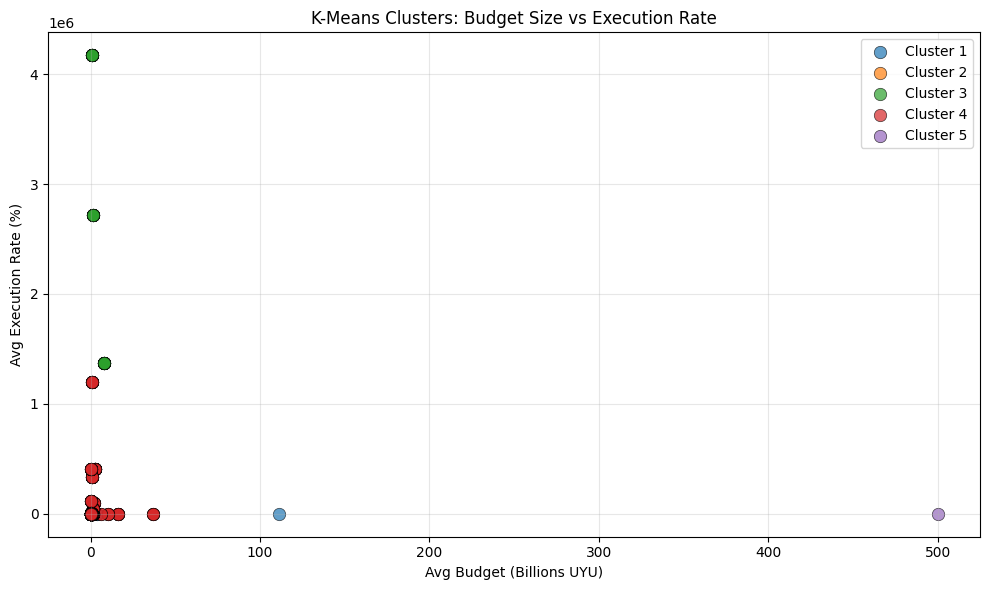

In [13]:
# Scatter plot of clusters: avg budget vs exec rate
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for cid in sorted(clusters_df["CENTROID_ID"].unique()):
    group = clusters_df[clusters_df["CENTROID_ID"] == cid]
    ax.scatter(
        group["avg_budget"] / 1e9,
        group["avg_exec_rate"],
        c=colors[cid - 1] if cid <= len(colors) else "gray",
        label=f"Cluster {cid}",
        s=80, alpha=0.7, edgecolors="black", linewidth=0.5,
    )
ax.set_xlabel("Avg Budget (Billions UYU)")
ax.set_ylabel("Avg Execution Rate (%)")
ax.set_title("K-Means Clusters: Budget Size vs Execution Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print("BQML analysis complete.")
print("Models created:")
print("  - opp_budget.budget_forecast  (LINEAR_REG)")
print("  - opp_budget.inciso_clusters  (KMEANS)")

BQML analysis complete.
Models created:
  - opp_budget.budget_forecast  (LINEAR_REG)
  - opp_budget.inciso_clusters  (KMEANS)
